# Module 3 — Time Series Analysis
**Course:** Data Mining 2 | **Dataset:** CMI Wrist Accelerometer (enmo signal)

This notebook covers:
1. **Data preparation** — load pkl.gz, drop non-wear series, train/test split by child id
2. **Exploratory analysis** — example series, average profiles, weekly patterns
3. **Motifs & discords** — Matrix Profile (STUMP algorithm)
4. **Time series clustering** — SAX+KMeans and Agglomerative/Ward with PCA + t-SNE
5. **Time series classification** — k-NN (Euclidean + DTW), ROCKET, Shapelet Transform

---
> **This notebook is self-contained** — it does NOT require Module 0–2 outputs.  
> Place `CMI_timeseries_dataset_pkl.gz` in the `../data/` folder.

## 3.0 — Setup: Imports and Paths

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gzip, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Time series ───────────────────────────────────────────────────────────────
import stumpy
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tslearn.piecewise import SymbolicAggregateApproximation
from tslearn.metrics import cdist_dtw

# ── Sktime classifiers ────────────────────────────────────────────────────────
from sktime.classification.kernel_based import RocketClassifier
from sktime.classification.shapelet_based import ShapeletTransformClassifier

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110
OUT_DIR   = '../outputs/'
DATA_PATH = '../data/CMI_timeseries_dataset.pkl.gz'
os.makedirs(OUT_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 3.1 — Load Time Series Dataset

In [2]:
print("DATA_PATH", DATA_PATH)
with gzip.open(DATA_PATH, 'rb') as f:
    raw = pickle.load(f)

print(f"Total series: {len(raw)}")
print(f"Example shape: {raw[0].shape}")
print(f"Columns: {raw[0].columns.tolist()}")
raw[0].head(3)

DATA_PATH ../data/CMI_timeseries_dataset.pkl.gz
Total series: 4437
Example shape: (200, 13)
Columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'weekday', 'quarter', 'relative_date_PCIAT', 'id', 'sii_binary']


,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.0,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.0,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.0,4.0,4.0,253.0,2265,0


In [3]:
# Check target distribution
sii_vals = [df['sii_binary'].iloc[0] for df in raw]
print("sii_binary distribution:")
print(pd.Series(sii_vals).value_counts(normalize=True).round(3))

# Check unique children
ids = [df['id'].iloc[0] for df in raw]
print(f"\nUnique children: {len(set(ids))}  |  Total series: {len(ids)}")

sii_binary distribution:
0    0.666
1    0.334
Name: proportion, dtype: float64

Unique children: 494  |  Total series: 4437


## 3.2 — Remove Non-Wear Series

In [4]:
keep_idx = [i for i, df in enumerate(raw) if df['non-wear_flag'].mean() == 0.0]
data     = [raw[i] for i in keep_idx]

print(f"Original series: {len(raw)}")
print(f"Kept (fully worn): {len(data)}  (removed {len(raw)-len(data)}, "
      f"{(1-len(data)/len(raw))*100:.2f}%)")

Original series: 4437
Kept (fully worn): 4258  (removed 179, 4.03%)


## 3.3 — Extract enmo Matrix and Metadata

In [5]:
enmo    = np.vstack([df['enmo'].values for df in data])          # (n, 200)
ids     = np.array([df['id'].iloc[0]    for df in data])
y       = np.array([df['sii_binary'].iloc[0] for df in data])
weekday = np.array([df['weekday'].iloc[0] for df in data])

print(f"enmo matrix: {enmo.shape}  (series × timesteps)")
print(f"sii_binary: {pd.Series(y).value_counts(normalize=True).round(3).to_dict()}")
print(f"Unique children: {len(np.unique(ids))}")

enmo matrix: (4258, 200)  (series × timesteps)
sii_binary: {0: 0.671, 1: 0.329}
Unique children: 326


## 3.4 — Train / Test Split (By Child ID — No Leakage)

In [6]:
unique_ids = np.unique(ids)
id_labels  = np.array([y[ids == uid][0] for uid in unique_ids])

train_ids, test_ids = train_test_split(
    unique_ids, test_size=0.25, stratify=id_labels, random_state=RANDOM_STATE
)

train_mask = np.isin(ids, train_ids)
test_mask  = np.isin(ids, test_ids)

print(f"Train: {train_mask.sum()} series from {len(train_ids)} children")
print(f"Test:  {test_mask.sum()} series from {len(test_ids)} children")
print(f"Train sii balance: {pd.Series(y[train_mask]).value_counts(normalize=True).round(3).to_dict()}")

np.savez(OUT_DIR + 'ts_data.npz',
         enmo=enmo, y=y, ids=ids, weekday=weekday,
         train_mask=train_mask, test_mask=test_mask)
print("\nts_data.npz saved.")

Train: 3094 series from 244 children
Test:  1164 series from 82 children
Train sii balance: {0: 0.666, 1: 0.334}

ts_data.npz saved.


---
## Part A — Exploratory Analysis

## 3.5 — Example Series per Class (Figure 3.1)

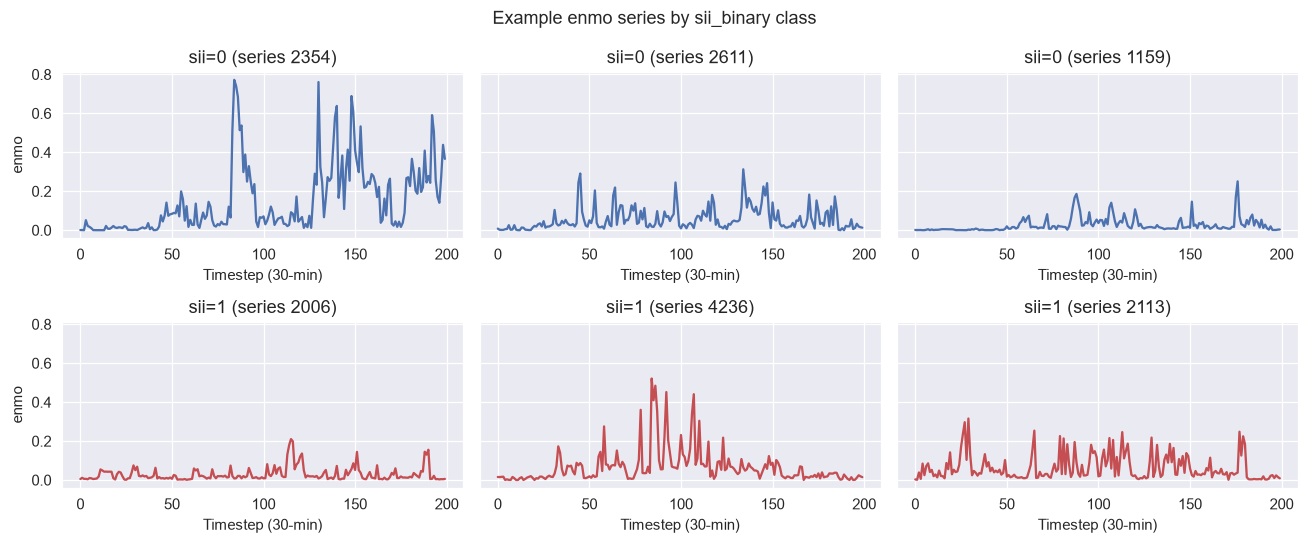

In [7]:
rng  = np.random.RandomState(RANDOM_STATE)
idx0 = rng.choice(np.where(y == 0)[0], 3, replace=False)
idx1 = rng.choice(np.where(y == 1)[0], 3, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharey=True)
for j, i in enumerate(idx0):
    axes[0, j].plot(enmo[i], color='#4C72B0')
    axes[0, j].set_title(f'sii=0 (series {i})')
for j, i in enumerate(idx1):
    axes[1, j].plot(enmo[i], color='#C44E52')
    axes[1, j].set_title(f'sii=1 (series {i})')
for ax in axes.flat:
    ax.set_xlabel('Timestep (30-min)')
axes[0, 0].set_ylabel('enmo'); axes[1, 0].set_ylabel('enmo')
plt.suptitle('Example enmo series by sii_binary class')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig14_example_series.png', dpi=110); plt.show()

## 3.6 — Average Profile per Class ± Std (Figure 3.2)

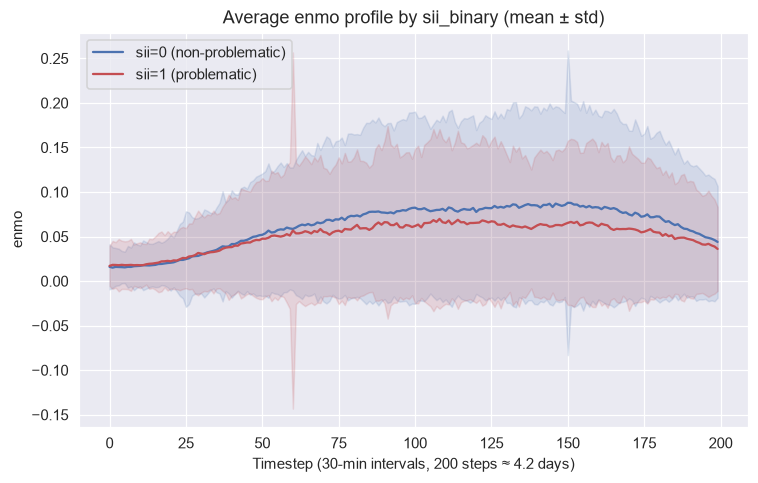

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for cls, color, label in [(0, '#4C72B0', 'sii=0 (non-problematic)'),
                            (1, '#C44E52', 'sii=1 (problematic)')]:
    mask = y == cls
    mean = enmo[mask].mean(axis=0)
    std  = enmo[mask].std(axis=0)
    ax.plot(mean, color=color, label=label)
    ax.fill_between(range(200), mean-std, mean+std, color=color, alpha=0.15)
ax.set_xlabel('Timestep (30-min intervals, 200 steps ≈ 4.2 days)')
ax.set_ylabel('enmo')
ax.set_title('Average enmo profile by sii_binary (mean ± std)')
ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig15_avg_profile_by_class.png', dpi=110); plt.show()

## 3.7 — Weekly Activity Pattern (Figure 3.3)

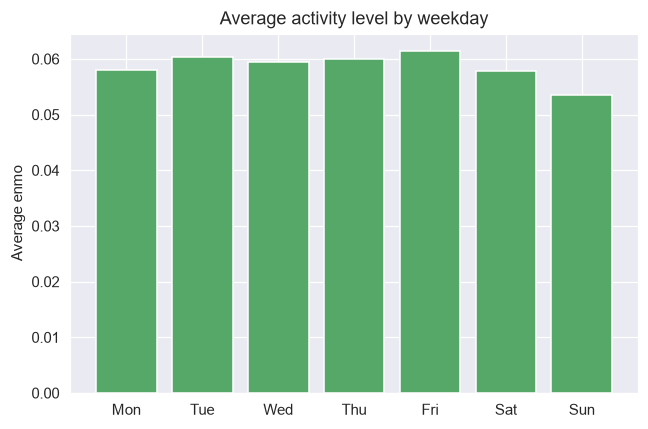

In [9]:
mean_enmo = enmo.mean(axis=1)
df_week   = pd.DataFrame({'weekday': weekday, 'mean_enmo': mean_enmo})
weekly    = df_week.groupby('weekday')['mean_enmo'].mean()
days      = {1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat',7:'Sun'}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([days.get(int(w), w) for w in weekly.index], weekly.values, color='#55A868')
ax.set_ylabel('Average enmo')
ax.set_title('Average activity level by weekday')
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig16_weekly_pattern.png', dpi=110); plt.show()

---
## Part B — Motifs and Discords (Matrix Profile)

The **Matrix Profile** (STUMP algorithm from `stumpy`) identifies:
- **Motif** = most frequently recurring subsequence (lowest MP value)
- **Discord** = most anomalous subsequence (highest MP value)

Window size = **10 timesteps = 5 hours**.

## 3.8 — Matrix Profile: Motifs and Discords (Figure 3.4)

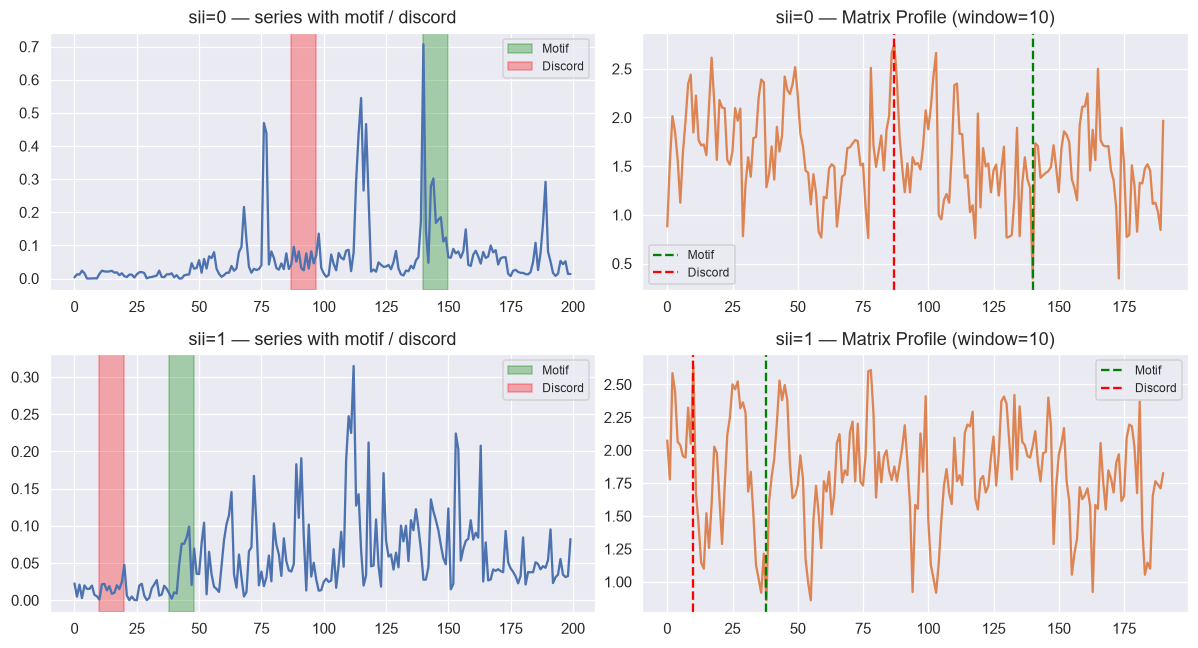

In [10]:
WINDOW = 10

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for row, (idx, label) in enumerate([
    (rng.choice(np.where(y==0)[0], 1)[0], 'sii=0'),
    (rng.choice(np.where(y==1)[0], 1)[0], 'sii=1'),
]):
    series      = enmo[idx].astype(np.float64)
    mp          = stumpy.stump(series, m=WINDOW)
    profile     = mp[:, 0].astype(float)
    motif_idx   = int(np.argmin(profile))
    discord_idx = int(np.argmax(profile))

    axes[row, 0].plot(series, color='#4C72B0')
    axes[row, 0].axvspan(motif_idx,   motif_idx   + WINDOW, color='green', alpha=0.3, label='Motif')
    axes[row, 0].axvspan(discord_idx, discord_idx + WINDOW, color='red',   alpha=0.3, label='Discord')
    axes[row, 0].set_title(f'{label} — series with motif / discord'); axes[row, 0].legend(fontsize=8)

    axes[row, 1].plot(profile, color='#DD8452')
    axes[row, 1].axvline(motif_idx,   color='green', linestyle='--', label='Motif')
    axes[row, 1].axvline(discord_idx, color='red',   linestyle='--', label='Discord')
    axes[row, 1].set_title(f'{label} — Matrix Profile (window={WINDOW})'); axes[row, 1].legend(fontsize=8)

plt.tight_layout(); plt.savefig(OUT_DIR + 'fig17_motifs_discords.png', dpi=110); plt.show()

---
## Part C — Time Series Clustering

Clustering is performed at the **child level** (one average enmo profile per child).  
Each profile is **z-score normalised** (per child) so that clustering captures shape, not amplitude.

Two algorithms, k=3 clusters each:
- **A) SAX + KMeans** — symbolic representation → KMeans
- **B) Agglomerative (Ward linkage)** — direct on normalised profiles

## 3.9 — Per-Child Average Profiles

In [11]:
unique_ids     = np.unique(ids)
child_profiles = np.array([enmo[ids == uid].mean(axis=0) for uid in unique_ids])
child_y        = np.array([y[ids == uid][0]              for uid in unique_ids])

# Z-score normalise (shape-based clustering)
mu   = child_profiles.mean(axis=1, keepdims=True)
sig  = child_profiles.std(axis=1,  keepdims=True)
norm = (child_profiles - mu) / (sig + 1e-8)

print(f"Per-child profiles: {child_profiles.shape}  |  sii balance: "
      f"{pd.Series(child_y).value_counts(normalize=True).round(3).to_dict()}")

Per-child profiles: (326, 200)  |  sii balance: {0: 0.632, 1: 0.368}


## 3.10 — Clustering A: SAX + KMeans

In [12]:
sax      = SymbolicAggregateApproximation(n_segments=20, alphabet_size_avg=5)
norm_3d  = norm.reshape(norm.shape[0], norm.shape[1], 1).astype(np.float64)
sax_repr = sax.fit_transform(norm_3d).reshape(norm.shape[0], -1)

kmeans       = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters_sax = kmeans.fit_predict(sax_repr)

print("SAX+KMeans cluster sizes:", pd.Series(clusters_sax).value_counts().to_dict())
ct_sax = pd.crosstab(clusters_sax, child_y, normalize='index') * 100
ct_sax.columns = ['sii=0', 'sii=1']
print("\nsii_binary distribution per cluster (%):")
print(ct_sax.round(1))

SAX+KMeans cluster sizes: {0: 133, 2: 109, 1: 84}

sii_binary distribution per cluster (%):
       sii=0  sii=1
row_0              
0       70.7   29.3
1       48.8   51.2
2       65.1   34.9


## 3.11 — Clustering B: Agglomerative (Ward)

In [13]:
ward         = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_ward = ward.fit_predict(norm)

print("Ward cluster sizes:", pd.Series(clusters_ward).value_counts().to_dict())
ct_ward = pd.crosstab(clusters_ward, child_y, normalize='index') * 100
ct_ward.columns = ['sii=0', 'sii=1']
print("\nsii_binary distribution per cluster (%):")
print(ct_ward.round(1))

Ward cluster sizes: {1: 147, 0: 127, 2: 52}

sii_binary distribution per cluster (%):
       sii=0  sii=1
row_0              
0       66.1   33.9
1       66.7   33.3
2       46.2   53.8


## 3.12 — Dimensionality Reduction: PCA + t-SNE (Figure 3.5)

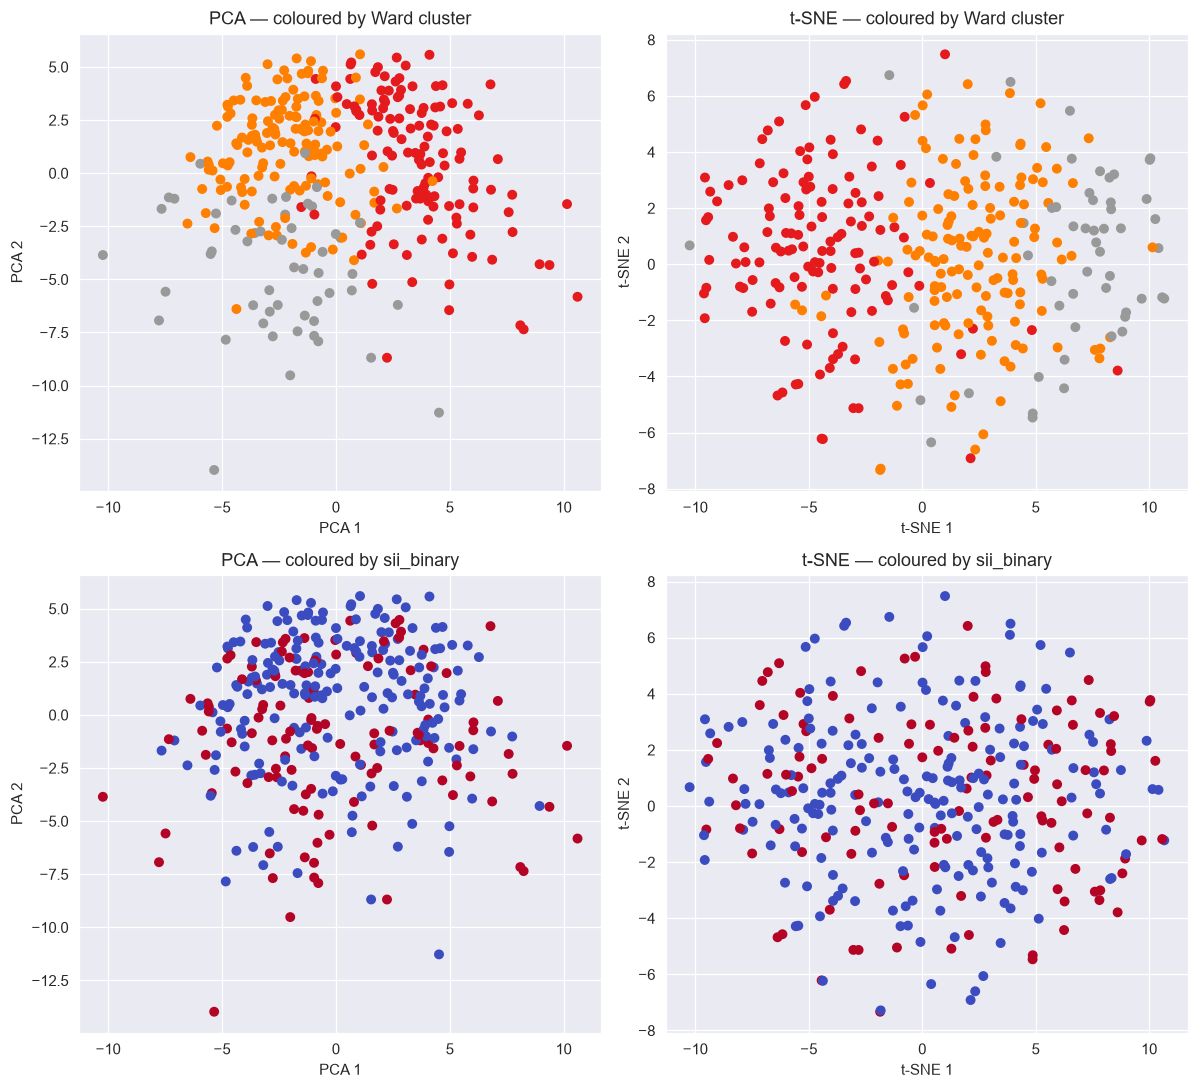

In [14]:
pca  = PCA(n_components=2, random_state=RANDOM_STATE)
pca_proj  = pca.fit_transform(norm)

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca')
tsne_proj = tsne.fit_transform(norm)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, proj, name in [(axes[0,0], pca_proj, 'PCA'), (axes[0,1], tsne_proj, 't-SNE')]:
    ax.scatter(proj[:,0], proj[:,1], c=clusters_ward, cmap='Set1', s=30)
    ax.set_title(f'{name} — coloured by Ward cluster')
    ax.set_xlabel(f'{name} 1'); ax.set_ylabel(f'{name} 2')

for ax, proj, name in [(axes[1,0], pca_proj, 'PCA'), (axes[1,1], tsne_proj, 't-SNE')]:
    ax.scatter(proj[:,0], proj[:,1], c=child_y, cmap='coolwarm', s=30)
    ax.set_title(f'{name} — coloured by sii_binary')
    ax.set_xlabel(f'{name} 1'); ax.set_ylabel(f'{name} 2')

plt.tight_layout(); plt.savefig(OUT_DIR + 'fig18_clustering_dimred.png', dpi=110); plt.show()

## 3.13 — Cluster Profiles + sii Distribution (Figure 3.6)

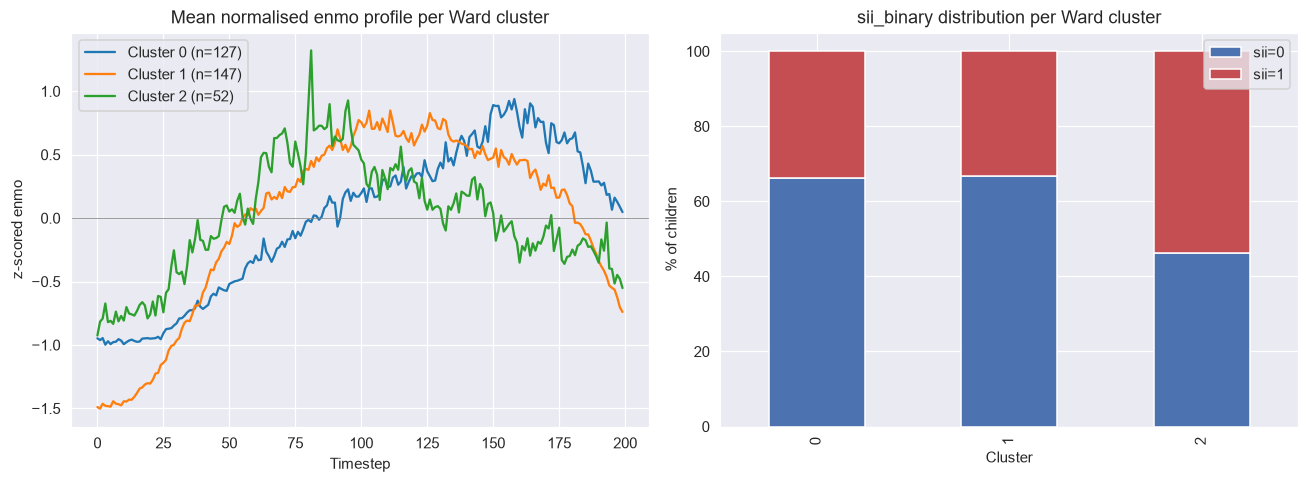

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for cl in np.unique(clusters_ward):
    mask = clusters_ward == cl
    axes[0].plot(norm[mask].mean(axis=0), label=f'Cluster {cl} (n={mask.sum()})')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].set_title('Mean normalised enmo profile per Ward cluster')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('z-scored enmo'); axes[0].legend()

ct_ward.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C72B0','#C44E52'])
axes[1].set_title('sii_binary distribution per Ward cluster')
axes[1].set_ylabel('% of children'); axes[1].set_xlabel('Cluster'); axes[1].legend()

plt.tight_layout(); plt.savefig(OUT_DIR + 'fig19_cluster_profiles_sii.png', dpi=110); plt.show()

---
## Part D — Time Series Classification

Target: `sii_binary` (per series).  
All series are **z-score normalised** before classification.

| Method | Notes |
|--------|-------|
| k-NN Euclidean | k ∈ {3,5,7,9,11}, full test set |
| k-NN DTW (Sakoe-Chiba) | radius ∈ {1,3,5}, k ∈ {3,5,7}, **subsampled** for speed |
| ROCKET | 500 random kernels, full train/test set |
| Shapelet Transform | 500-series train subsample, time-limited to 8 min |

## 3.14 — Prepare Data

In [16]:
X_train_ts = enmo[train_mask]
X_test_ts  = enmo[test_mask]
y_train_ts = y[train_mask]
y_test_ts  = y[test_mask]

# Z-score normalise per series
def znorm(X):
    mu  = X.mean(axis=1, keepdims=True)
    sig = X.std(axis=1,  keepdims=True)
    return (X - mu) / (sig + 1e-8)

X_tr_n = znorm(X_train_ts)
X_te_n = znorm(X_test_ts)

print(f"Train: {X_tr_n.shape}  |  Test: {X_te_n.shape}")
print(f"sii balance (train): {pd.Series(y_train_ts).value_counts(normalize=True).round(3).to_dict()}")

Train: (3094, 200)  |  Test: (1164, 200)
sii balance (train): {0: 0.666, 1: 0.334}


## 3.15 — k-NN with Euclidean Distance

In [17]:
best_k, best_f1, pred_euc = None, -1, None
for k in [3, 5, 7, 9, 11]:
    knn  = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_tr_n, y_train_ts)
    pred = knn.predict(X_te_n)
    f1   = classification_report(y_test_ts, pred, output_dict=True)['macro avg']['f1-score']
    print(f"  k={k}: macro-F1 = {f1:.3f}")
    if f1 > best_f1:
        best_f1, best_k, pred_euc = f1, k, pred

print(f"\nBest: k={best_k}, macro-F1={best_f1:.3f}")
print(classification_report(y_test_ts, pred_euc, digits=2))
np.save(OUT_DIR + 'pred_euc.npy', pred_euc)

  k=3: macro-F1 = 0.507
  k=5: macro-F1 = 0.507
  k=7: macro-F1 = 0.481
  k=9: macro-F1 = 0.468
  k=11: macro-F1 = 0.447

Best: k=5, macro-F1=0.507
              precision    recall  f1-score   support

           0       0.69      0.86      0.77       793
           1       0.38      0.18      0.25       371

    accuracy                           0.64      1164
   macro avg       0.54      0.52      0.51      1164
weighted avg       0.59      0.64      0.60      1164



## 3.16 — k-NN with DTW (Sakoe-Chiba, subsampled)

In [18]:
rng_sub = np.random.RandomState(RANDOM_STATE)
n_sub_tr, n_sub_te = 400, 200

sub_tr = rng_sub.choice(len(X_tr_n), n_sub_tr, replace=False)
sub_te = rng_sub.choice(len(X_te_n), n_sub_te, replace=False)

X_tr_sub = X_tr_n[sub_tr]; y_tr_sub = y_train_ts[sub_tr]
X_te_sub = X_te_n[sub_te]; y_te_sub = y_test_ts[sub_te]

best_dtw = {'f1': -1}
for radius in [1, 3, 5]:
    print(f"Computing DTW distances (radius={radius})...", end=' ')
    dist = cdist_dtw(X_te_sub, X_tr_sub,
                     global_constraint='sakoe_chiba', sakoe_chiba_radius=radius)
    for k in [3, 5, 7]:
        nn_labels = y_tr_sub[np.argsort(dist, axis=1)[:, :k]]
        pred      = (nn_labels.mean(axis=1) >= 0.5).astype(int)
        f1        = classification_report(y_te_sub, pred, output_dict=True)['macro avg']['f1-score']
        print(f"k={k}→F1={f1:.3f}", end='  ')
        if f1 > best_dtw['f1']:
            best_dtw = {'f1': f1, 'radius': radius, 'k': k, 'pred': pred}
    print()

print(f"\nBest DTW: radius={best_dtw['radius']}, k={best_dtw['k']}, macro-F1={best_dtw['f1']:.3f}")
print(classification_report(y_te_sub, best_dtw['pred'], digits=2))

Computing DTW distances (radius=1)... k=3→F1=0.470  k=5→F1=0.495  k=7→F1=0.460  
Computing DTW distances (radius=3)... k=3→F1=0.484  k=5→F1=0.505  k=7→F1=0.481  
Computing DTW distances (radius=5)... k=3→F1=0.480  k=5→F1=0.481  k=7→F1=0.484  

Best DTW: radius=3, k=5, macro-F1=0.505
              precision    recall  f1-score   support

           0       0.70      0.88      0.78       138
           1       0.38      0.16      0.23        62

    accuracy                           0.66       200
   macro avg       0.54      0.52      0.50       200
weighted avg       0.60      0.66      0.61       200



## 3.17 — ROCKET Classifier

In [19]:
X_tr_3d = X_tr_n.reshape(X_tr_n.shape[0], 1, X_tr_n.shape[1])
X_te_3d = X_te_n.reshape(X_te_n.shape[0], 1, X_te_n.shape[1])

rocket = RocketClassifier(num_kernels=500, random_state=RANDOM_STATE, n_jobs=-1)
rocket.fit(X_tr_3d, y_train_ts)
pred_rocket = rocket.predict(X_te_3d)

print("ROCKET:")
print(classification_report(y_test_ts, pred_rocket, digits=2))
np.save(OUT_DIR + 'pred_rocket.npy', pred_rocket)

ROCKET:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       793
           1       0.37      0.18      0.24       371

    accuracy                           0.64      1164
   macro avg       0.53      0.52      0.50      1164
weighted avg       0.59      0.64      0.60      1164



## 3.18 — Shapelet Transform Classifier

In [20]:
# Subsample training set for shapelet search (computationally expensive)
n_shap_sub = 500
sub_shap   = rng_sub.choice(len(X_tr_n), n_shap_sub, replace=False)
X_tr_shap  = X_tr_n[sub_shap].reshape(n_shap_sub, 1, X_tr_n.shape[1])
y_tr_shap  = y_train_ts[sub_shap]

print(f"Shapelet training on {n_shap_sub} series (full test set: {len(X_te_3d)})...")

shapelet_clf = ShapeletTransformClassifier(
    n_shapelet_samples=100,
    max_shapelets=10,
    time_limit_in_minutes=8,
    random_state=RANDOM_STATE,
)
shapelet_clf.fit(X_tr_shap, y_tr_shap)
pred_shapelet = shapelet_clf.predict(X_te_3d)

print("Shapelet Transform:")
print(classification_report(y_test_ts, pred_shapelet, digits=2))
np.save(OUT_DIR + 'pred_shapelet.npy', pred_shapelet)

Shapelet training on 500 series (full test set: 1164)...
Shapelet Transform:
              precision    recall  f1-score   support

           0       0.69      0.70      0.69       793
           1       0.33      0.31      0.32       371

    accuracy                           0.58      1164
   macro avg       0.51      0.51      0.51      1164
weighted avg       0.57      0.58      0.57      1164



## 3.19 — Results Summary Table

In [21]:
def get_metrics(y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Accuracy':        rep['accuracy'],
        'Macro Precision': rep['macro avg']['precision'],
        'Macro Recall':    rep['macro avg']['recall'],
        'Macro F1':        rep['macro avg']['f1-score'],
    }

results = [
    {'Method': f'k-NN Euclidean (k={best_k})',
     **get_metrics(y_test_ts, pred_euc)},

    {'Method': f"k-NN DTW (r={best_dtw['radius']}, k={best_dtw['k']}, n={n_sub_te})",
     **get_metrics(y_te_sub, best_dtw['pred'])},

    {'Method': 'ROCKET (500 kernels)',
     **get_metrics(y_test_ts, pred_rocket)},

    {'Method': f'Shapelet (train n={n_shap_sub})',
     **get_metrics(y_test_ts, pred_shapelet)},
]

res_df = pd.DataFrame(results)
res_df.to_csv(OUT_DIR + 'table_ts_classification_results.csv', index=False)
print(res_df.round(3).to_string(index=False))



                    Method  Accuracy  Macro Precision  Macro Recall  Macro F1
      k-NN Euclidean (k=5)     0.644            0.536         0.522     0.507
k-NN DTW (r=3, k=5, n=200)     0.660            0.543         0.523     0.505
      ROCKET (500 kernels)     0.639            0.529         0.518     0.504
    Shapelet (train n=500)     0.578            0.507         0.507     0.507


## 3.20 — Macro-F1 Comparison (Figure 3.7)

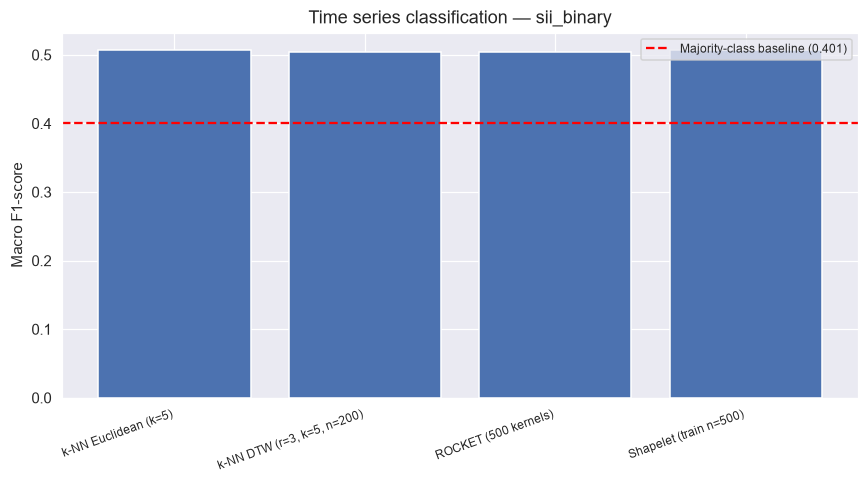

In [22]:
majority_f1 = 0.401  # majority-class baseline for 67/33 split

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(res_df['Method'], res_df['Macro F1'], color='#4C72B0')
ax.axhline(majority_f1, color='red', linestyle='--', label=f'Majority-class baseline ({majority_f1})')
ax.set_ylabel('Macro F1-score')
ax.set_title('Time series classification — sii_binary')
ax.legend(fontsize=8)
plt.xticks(rotation=20, ha='right', fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig20_ts_classification_comparison.png', dpi=110); plt.show()

## 3.21 — Confusion Matrices (Figure 3.8)

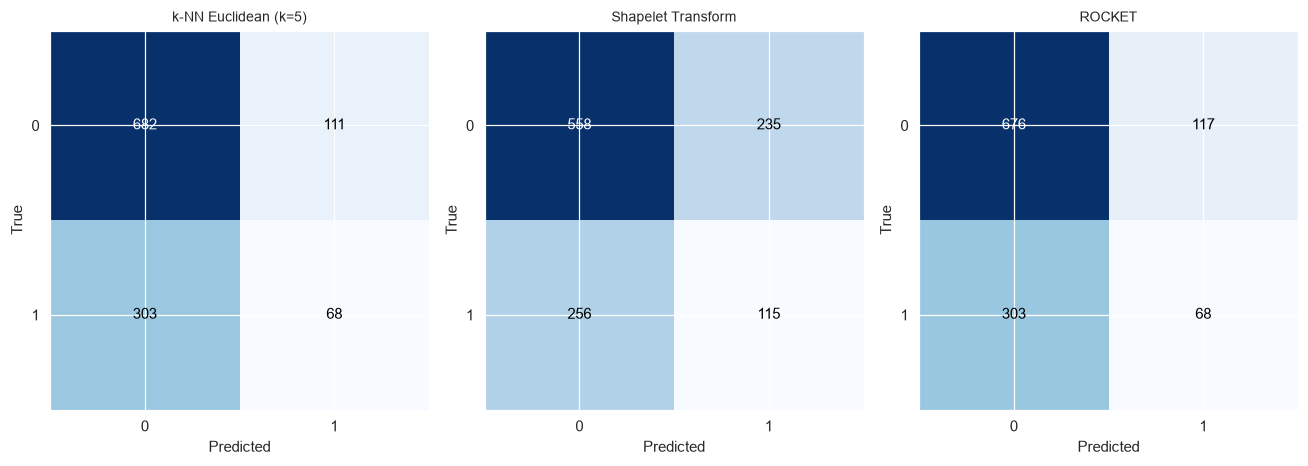

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (pred, name, y_true) in zip(axes, [
    (pred_euc,      f'k-NN Euclidean (k={best_k})', y_test_ts),
    (pred_shapelet, 'Shapelet Transform',            y_test_ts),
    (pred_rocket,   'ROCKET',                        y_test_ts),
]):
    cm = confusion_matrix(y_true, pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.savefig(OUT_DIR + 'fig21_ts_confusion_matrices.png', dpi=110); plt.show()

In [24]:
print("✅ Module 3 complete. All time series outputs saved to:", OUT_DIR)

✅ Module 3 complete. All time series outputs saved to: ../outputs/
